In [340]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

**Try to get the network of Myxo Model**

Import Model and Data

In [341]:
M_xanthus = read_sbml_model("../M_xanthus_model_V3.xml")
M_xanthus

Name,myxo_model
Memory address,7f9652c51be0
Number of metabolites,1223
Number of reactions,1337
Number of genes,1200
Number of groups,0
Objective expression,1.0*OF_BIOMASS - 1.0*OF_BIOMASS_reverse_80d2e
Compartments,"c, e"


In [342]:
iMAT_res = pd.read_csv("/home/mickael/github/M_xanthus-E_coli-Predation/results/Model_V3_hdca/iMAT/Ec1_Predation/epsilon_1.0_quantiles_40_70.tsv", sep="\t")
iMAT_res_predation = iMAT_res[iMAT_res.flux_value != 0] # take all the flux different from 0 (so active one)
iMAT_res_predation

,reaction_id,flux_value,classification,y_f,y_r
1,rxn00351_c,1.000000,high,1.0,0.0
2,rxn07431_c,-433.142860,high,0.0,1.0
3,rxn00836_c,-1.000000,high,0.0,1.0
7,rxn00364_c,-2.000000,moderate,NaN,NaN
12,rxn00646_c,1.000000,high,1.0,0.0
...,...,...,...,...,...
1321,EX_tsul_e,-1.666667,NaN,NaN,NaN
1332,rxn00899_c,433.142860,high,1.0,0.0
1335,rxn09888_c,2.000000,NaN,NaN,NaN
1337,EX_hdca_e,-1.000000,NaN,NaN,NaN


In [343]:
iMAT_res_2 = pd.read_csv("/home/mickael/github/M_xanthus-E_coli-Predation/results/Model_V3_hdca/iMAT/W1_Alone/epsilon_1.0_quantiles_40_70.tsv", sep="\t")
iMAT_res_alone = iMAT_res_2[iMAT_res_2.flux_value != 0] # take all the flux different from 0 (so active one)
iMAT_res_alone

,reaction_id,flux_value,classification,y_f,y_r
1,rxn00351_c,1.0,moderate,NaN,NaN
2,rxn07431_c,1.0,high,1.0,0.0
7,rxn00364_c,-2.0,moderate,NaN,NaN
12,rxn00646_c,1.0,moderate,NaN,NaN
14,rxn01673_c,1.0,high,1.0,0.0
...,...,...,...,...,...
1332,rxn00899_c,-1.0,high,0.0,1.0
1335,rxn09888_c,2.0,NaN,NaN,NaN
1336,rxn06033_c,-1.0,NaN,NaN,NaN
1337,EX_hdca_e,-199.6,NaN,NaN,NaN


Get the information

In [344]:
reaction_alone = []
for i in iMAT_res_alone["reaction_id"]:
    reaction_alone.append(i)

reactions = []
for i in iMAT_res_predation["reaction_id"]:
    if i not in reaction_alone:
        reactions.append(i)

metabolites = []
for i in M_xanthus.metabolites._dict:
    metabolites.append(i)

Create the graph

In [345]:
Mx = nx.DiGraph() # Create a directed graph
Mx.add_nodes_from(metabolites) # add all metabolites as nodes

In [346]:
allowed = []
for j in reactions:
    M = M_xanthus.reactions.get_by_id(j).reaction.split()
    for i in M:
        if i not in allowed:
            allowed.append(i)

In [347]:
remove = []
for i in Mx.nodes:
    if i not in allowed:
        remove.append(i)
        

Mx.remove_nodes_from(remove)

In [348]:
# for i in range(len(list(Mx.nodes))):
#     count = i+1
#     while count < len(list(Mx.nodes)):
#         for k in reactions:
#             if "<=>" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is bidirectional
#                 if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split()[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split()[1] or list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("<=>")[1] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("<=>")[0]:
#                     Mx.add_edge(list(Mx.nodes)[i], list(Mx.nodes)[count]) # add the edge
#                     Mx.add_edge(list(Mx.nodes)[count], list(Mx.nodes)[i]) # add the edge
#                     Mx.edges[(list(Mx.nodes)[i], list(Mx.nodes)[count])]["id"] = k # add reaction id to the edge information
#                     Mx.edges[(list(Mx.nodes)[count], list(Mx.nodes)[i])]["id"] = k # add reaction id to the edge information
#             if "-->" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is foward
#                 if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("-->")[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("-->")[1]:
#                     Mx.add_edge(list(Mx.nodes)[i], list(Mx.nodes)[count]) # add the edge
#                     Mx.edges[(list(Mx.nodes)[i], list(Mx.nodes)[count])]["id"] = k # add reaction id to the edge information
#             if "<--" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is reverse
#                 if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("<--")[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("<--")[1]:
#                     Mx.add_edge(list(Mx.nodes)[count], list(Mx.nodes)[i]) # add the edge
#                     Mx.edges[(list(Mx.nodes)[count], list(Mx.nodes)[i])]["id"] = k # add reaction id to the edge information
#         count += 1

In [350]:
for i in range(len(list(Mx.nodes))):
    count = i+1
    while count < len(list(Mx.nodes)):
        for k in reactions:
            if "<=>" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is bidirectional
                if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split()[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split()[1] or list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("<=>")[1] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("<=>")[0]:
                    if float(iMAT_res_predation.loc[iMAT_res_predation['reaction_id'] == k, 'flux_value']) < 0:
                        Mx.add_edge(list(Mx.nodes)[count], list(Mx.nodes)[i]) # add the edge
                        Mx.edges[(list(Mx.nodes)[count], list(Mx.nodes)[i])]["id"] = k # add reaction id to the edge information
                    if float(iMAT_res_predation.loc[iMAT_res_predation['reaction_id'] == k, 'flux_value']) > 0:
                        Mx.add_edge(list(Mx.nodes)[i], list(Mx.nodes)[count]) # add the edge
                        Mx.edges[(list(Mx.nodes)[i], list(Mx.nodes)[count])]["id"] = k # add reaction id to the edge information
            if "-->" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is foward
                if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("-->")[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("-->")[1]:
                    Mx.add_edge(list(Mx.nodes)[i], list(Mx.nodes)[count]) # add the edge
                    Mx.edges[(list(Mx.nodes)[i], list(Mx.nodes)[count])]["id"] = k # add reaction id to the edge information
            if "<--" in M_xanthus.reactions.get_by_id(k).reaction: # check if the reaction is reverse
                if list(Mx.nodes)[i] in M_xanthus.reactions.get_by_id(k).reaction.split("<--")[0] and list(Mx.nodes)[count] in M_xanthus.reactions.get_by_id(k).reaction.split("<--")[1]:
                    Mx.add_edge(list(Mx.nodes)[count], list(Mx.nodes)[i]) # add the edge
                    Mx.edges[(list(Mx.nodes)[count], list(Mx.nodes)[i])]["id"] = k # add reaction id to the edge information
        count += 1

/tmp/ipykernel_1862323/1815054601.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(iMAT_res_predation.loc[iMAT_res_predation['reaction_id'] == k, 'flux_value']) < 0:
/tmp/ipykernel_1862323/1815054601.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if float(iMAT_res_predation.loc[iMAT_res_predation['reaction_id'] == k, 'flux_value']) > 0:


In [359]:
Mx.number_of_edges()

194

In [352]:
# remove = []
# for i in Mx.nodes:
#     if Mx.degree[i] == 0:
#         remove.append(i)
# Mx.remove_nodes_from(remove)

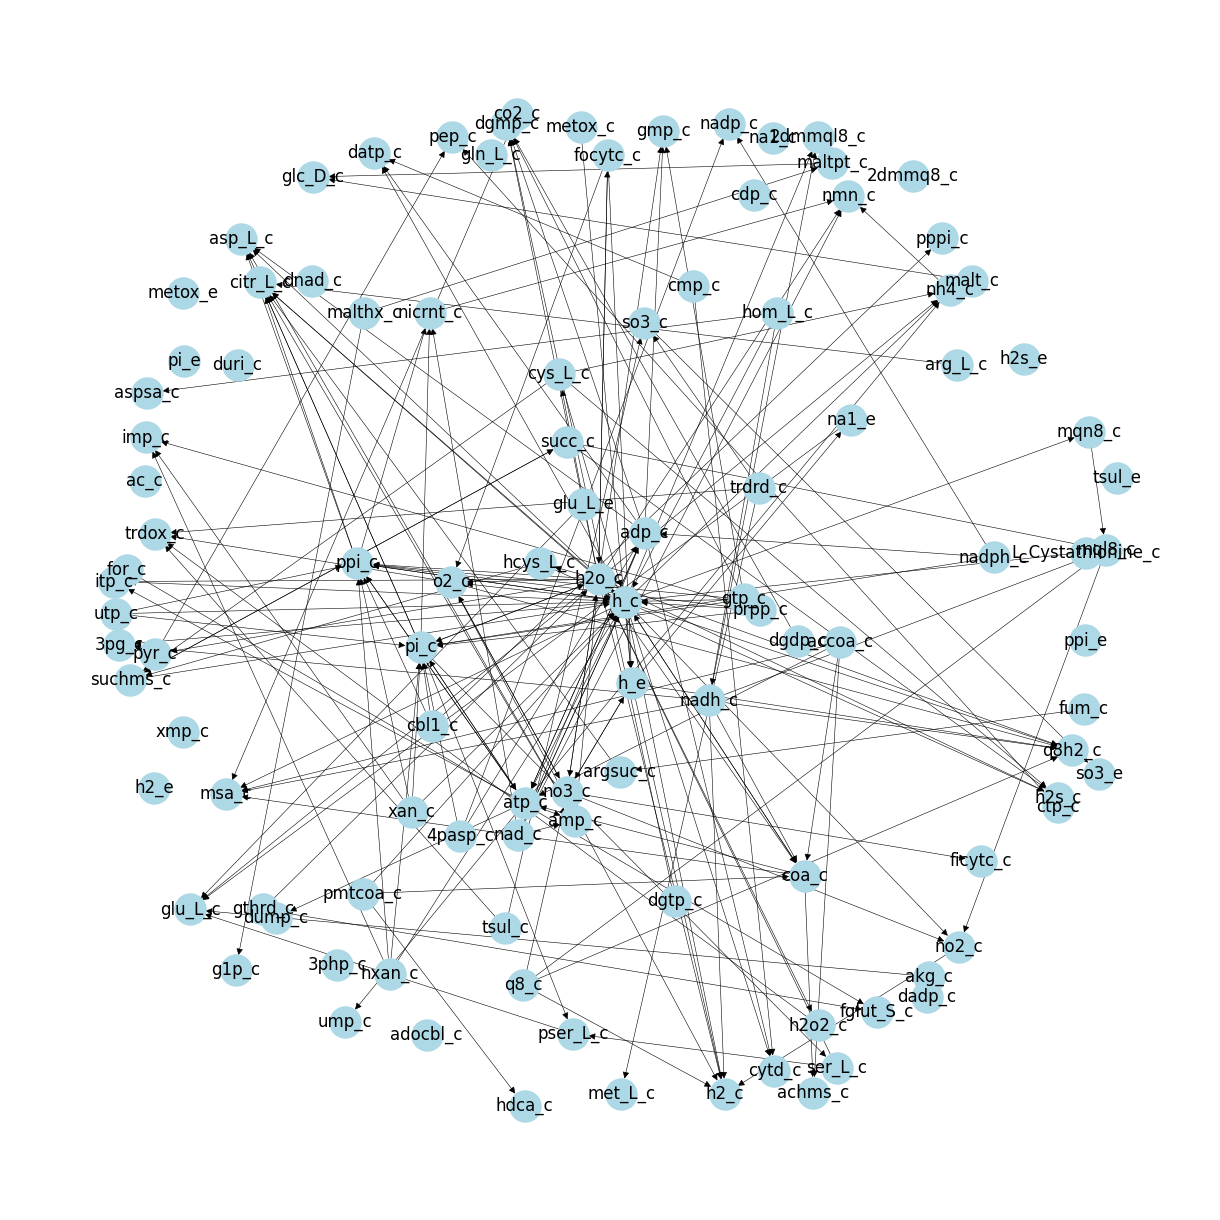

In [ ]:
plt.figure(figsize=(12,12))
pos = nx.spring_layout(Mx, k=0.9)
# edge_labels = nx.get_edge_attributes(Mx,'id')
# nx.draw_networkx_edge_labels(Mx, pos, edge_labels = edge_labels)
nx.draw(Mx, with_labels=True, pos = pos, width=0.4, node_color='lightblue', node_size=500)